Task 10 — DDPM Forward & Reverse Latent Optimization

This task uses PyTorch, Diffusers, NumPy, and Matplotlib. It focuses on adding noise through a forward process and then removing the noise through a reverse denoising process over 1000 timesteps.

In [1]:
# Import Libraries

import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create Image

image = torch.randn(1, 1, 28, 28)

print(image.shape)

torch.Size([1, 1, 28, 28])


In [3]:
# Set Timesteps

timesteps = 1000
beta_start = 0.0001
beta_end = 0.02

betas = torch.linspace(
    beta_start,
    beta_end,
    timesteps
)

In [4]:
# Calculate Alpha

alphas = 1 - betas

alpha_bar = torch.cumprod(
    alphas,
    dim=0
)

In [5]:
# Forward Noise Process

t = 500

noise = torch.randn_like(image)

noisy_image = (
    torch.sqrt(alpha_bar[t]) * image
    + torch.sqrt(1 - alpha_bar[t]) * noise
)

print(noisy_image.shape)

torch.Size([1, 1, 28, 28])


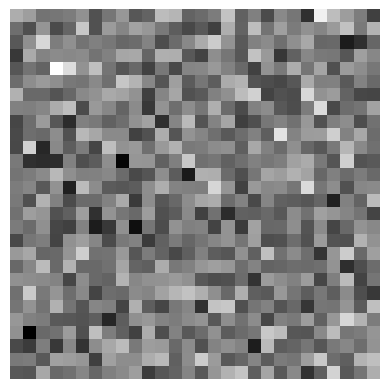

In [6]:
# Display Noisy Image

plt.imshow(
    noisy_image[0, 0].numpy(),
    cmap="gray"
)

plt.axis("off")
plt.show()

In [7]:
# Reverse Denoising Step

predicted_noise = torch.randn_like(noisy_image)

denoised_image = (
    noisy_image - predicted_noise
)

print(denoised_image.shape)

torch.Size([1, 1, 28, 28])


In [8]:
# Reverse Denoising Loop

x = noisy_image

for t in reversed(range(1000)):

    noise = torch.randn_like(x)

    x = (
        x - betas[t] * noise
    )

print(x.shape)

torch.Size([1, 1, 28, 28])


In [9]:
# Results

print("Original Shape:", image.shape)
print("Noisy Shape:", noisy_image.shape)
print("Final Shape:", x.shape)

Original Shape: torch.Size([1, 1, 28, 28])
Noisy Shape: torch.Size([1, 1, 28, 28])
Final Shape: torch.Size([1, 1, 28, 28])
